In [1]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
noise_sigma = 1
true_sigma = 1
true_mu = 0

Nobs = 100

observations = jnp.array([
    0.07235167, 0.08137235, 0.08400482, 0.09897746, 0.12829544,
    0.15858794, 0.18148971, 0.19041836, 0.19760933, 0.21548708,
    0.22668245, 0.23330388, 0.23423434, 0.25133409, 0.25649349,
    0.26416733, 0.31545178, 0.32693801, 0.34821519, 0.34972657,
    0.35032896, 0.35194977, 0.36062073, 0.36777869, 0.38098967,
    0.4055356 , 0.41466387, 0.45182982, 0.48488138, 0.50576141,
    0.50705147, 0.50757769, 0.51074019, 0.51834823, 0.55380499,
    0.59640212, 0.61798925, 0.63057743, 0.64632246, 0.67048612,
    0.68607896, 0.71081426, 0.71941826, 0.72922726, 0.73068674,
    0.73107743, 0.73942046, 0.81078744, 0.81262118, 0.82270788,
    0.83368154, 0.83494155, 0.88519018, 0.90938308, 0.9244017 ,
    0.93577661, 0.95533922, 1.00273094, 1.02389432, 1.06054882,
    1.07680367, 1.0779132 , 1.12786384, 1.14819763, 1.15558433,
    1.17612611, 1.17933912, 1.20561263, 1.24793551, 1.28182201,
    1.31441748, 1.34592975, 1.34787821, 1.38059889, 1.40323948,
    1.40701077, 1.41820729, 1.43756095, 1.4409888 , 1.48827552,
    1.51318633, 1.56786095, 1.72918018, 1.73349268, 1.77074591,
    1.81875729, 1.97070155, 2.00771461, 2.01933324, 2.13691939,
    2.16450117, 2.26052138, 2.30947318, 2.32435402, 2.38560946,
    2.64520255, 2.95363548, 3.34668038, 3.53367055, 3.67197778
])

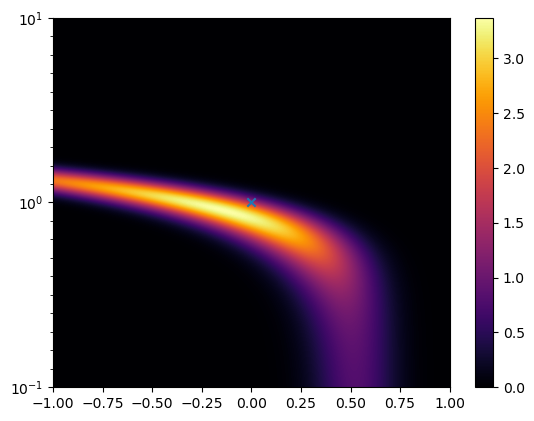

In [2]:
def log_likelihood_analytical(mu, sigma, observations=np.array(observations), Nobs=Nobs):
    norm = -Nobs/2 * np.log(2*np.pi * (sigma**2 + noise_sigma**2))
    selection = -Nobs * scipy.special.log_ndtr(mu / np.sqrt(sigma**2 + noise_sigma**2))
    o = np.expand_dims(observations, axis=tuple(range(len(np.shape(sigma)))))
    m = np.expand_dims(mu, axis=-1)
    arg = -np.sum((o - m)**2, axis=-1) / 2 / (sigma**2 + noise_sigma**2)
    return arg + norm + selection

sigmas = np.linspace(-1,1,1000)
mus = np.linspace(-1,1,1000)

dsigma = sigmas[1] - sigmas[0]
dmu = mus[1] - mus[0]

mu_mesh, sig_mesh = np.meshgrid(mus, sigmas)

lls = log_likelihood_analytical(mu_mesh, np.exp(np.log(10) * sig_mesh))
log_evidence = scipy.special.logsumexp(lls) + np.log(dsigma * dmu)
log_posterior = lls - log_evidence

im = plt.imshow(np.exp(log_posterior), cmap='inferno', origin='lower', extent=(mus[0], mus[-1], sigmas[0], sigmas[-1]), aspect='auto')
plt.colorbar(im)
plt.scatter(true_mu, np.log(true_sigma), marker='x')

plt.yticks(np.linspace(-1,1,21),minor=True)
plt.yticks([-1,0,1],['$10^{-1}$','$10^{0}$','$10^{1}$'])
plt.show()

In [3]:
def calculate_contour(log_p_array, contour=0.9):
    ln_p_sort = -jnp.sort(-log_p_array) # sort from big to small
    cdf = jnp.cumsum(jnp.exp(ln_p_sort))
    cdf /= cdf[-1] # normalize

    p_boundary = jnp.interp(contour, cdf, log_p_array) # pdf boundary between inner and outer contour
    return p_boundary

def draw_VT_sample(Ndraws, PRNGkey, draw_mu=0, draw_sigma=10):
    PRNGkey1, PRNGkey2 = jax.random.split(PRNGkey)
    latent = jax.random.normal(PRNGkey1, shape=(Ndraws,))
    VT_draws = latent * draw_sigma + draw_mu
    pdraw = -latent**2 / 2 - 0.5*jnp.log(2*np.pi*draw_sigma**2)
    noise = jax.random.normal(PRNGkey2, shape=(Ndraws,)) * noise_sigma
    log_pdraw = jnp.where(VT_draws + noise > 0, pdraw, jnp.inf)
    return VT_draws, log_pdraw

def draw_PE_sample(observations, NPE, PRNGkey):
    scatter = jax.random.normal(PRNGkey, shape=(len(observations), NPE)) * noise_sigma
    return jnp.expand_dims(observations, axis=1) + scatter

draw_PE_sample(observations, 1000, jax.random.PRNGKey(0)).shape

(100, 1000)

500it [02:11,  3.80it/s]


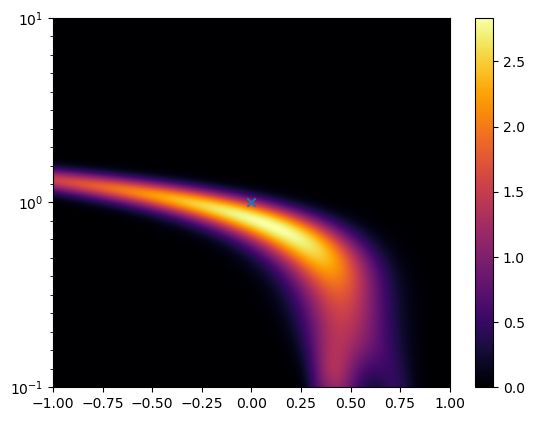

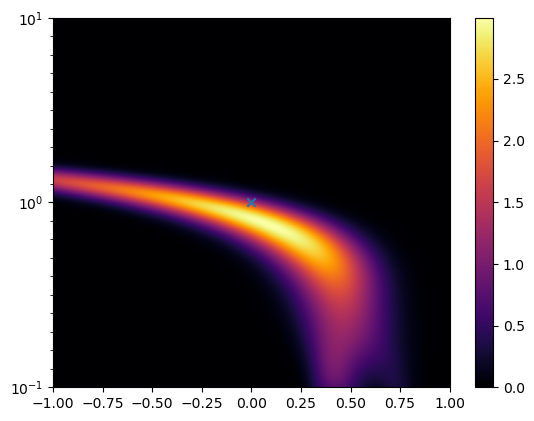

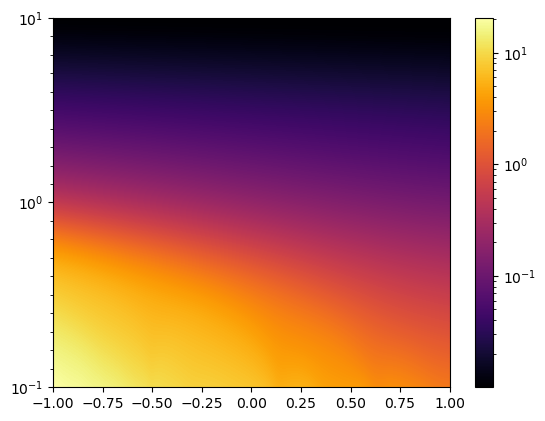

In [4]:
from jax.scipy.special import logsumexp as LSE

def log_gaussian(x, mu, sigma):
    return -(x - mu)**2 / 2 / sigma**2 - 0.5*jnp.log(2*jnp.pi) - jnp.log(sigma)

def get_random_sample(PRNGkey, NPE, NVT, observations=observations):

    obs_key, vt_key = jax.random.split(PRNGkey)
    observations_array = draw_PE_sample(observations, NPE, obs_key)
    detected_vt_array, ln_p_vt = draw_VT_sample(NVT, vt_key)
    return observations_array, detected_vt_array, ln_p_vt

def naive_log_likelihood_estimator(mu, sigma, observations_array, detected_vt_array, ln_p_vt, Nobs=Nobs):
    # expand dims to right shapes
    num_dimension = len(jnp.shape(mu))    # assume shapes are same for mu and sigma
    observations_array = jnp.expand_dims(observations_array, axis=tuple([2+ii for ii in range(num_dimension)]))
    detected_vt_array = jnp.expand_dims(detected_vt_array, axis=tuple([1+ii for ii in range(num_dimension)]))
    ln_p_vt = jnp.expand_dims(ln_p_vt, axis=tuple([1+ii for ii in range(num_dimension)]))

    obs_weights = log_gaussian(observations_array, mu[None,None,...], sigma[None,None,...])
    vt_weights = log_gaussian(detected_vt_array, mu[None,...], sigma[None,...]) - ln_p_vt

    NPE = obs_weights.shape[1]
    NVT = vt_weights.shape[0]

    numerator = LSE(obs_weights, axis=1) - jnp.log(NPE)
    denominator = LSE(vt_weights, axis=0) - jnp.log(NVT)
    # print(numerator, denominator)

    loglikelihood = jnp.sum(numerator, axis=0) - Nobs * denominator

    var_numerator = jnp.exp(LSE(2*obs_weights, axis=1) - 2*jnp.log(NPE) - 2*numerator) - 1/NPE
    var_denominator = jnp.exp(LSE(2*vt_weights, axis=0) - 2*jnp.log(NVT) - 2*denominator) - 1/NVT

    num_variance = jnp.sum(var_numerator, axis=0)
    denom_variance = Nobs**2 * var_denominator

    correction = Nobs * (Nobs + 1) * var_denominator / 2
    return loglikelihood, loglikelihood - correction, num_variance, denom_variance

npe = 1000
nvt = int(1e6)
PRNGkey = jax.random.PRNGKey(0)
sigmas = jnp.linspace(-1,1,500)
mus = jnp.linspace(-1,1,500)

dsigma = sigmas[1] - sigmas[0]
dmu = mus[1] - mus[0]

mu_mesh, sig_mesh = jnp.meshgrid(mus, sigmas)

observations_array, detected_vt_array, ln_p_vt = get_random_sample(PRNGkey, npe, nvt, observations=observations)

lls = []
llcs = []
llvs = []

from tqdm import tqdm
for m, s in tqdm(zip(mu_mesh, sig_mesh)):
    ll, llc, llv = naive_log_likelihood_estimator(m, jnp.exp(jnp.log(10) * s), observations_array, detected_vt_array, ln_p_vt)
    lls.append(ll)
    llcs.append(llc)
    llvs.append(llv)

lls = np.array(lls)
llcs = np.array(llcs)
llvs = np.array(llvs)

log_evidence = LSE(lls) + jnp.log(dsigma * dmu)
log_posterior = lls - log_evidence

im = plt.imshow(jnp.exp(log_posterior), cmap='inferno', origin='lower', extent=(mus[0], mus[-1], sigmas[0], sigmas[-1]), aspect='auto')
plt.colorbar(im)
plt.scatter(true_mu, np.log(true_sigma), marker='x')

plt.yticks(np.linspace(-1,1,21),minor=True)
plt.yticks([-1,0,1],['$10^{-1}$','$10^{0}$','$10^{1}$'])
plt.show()

log_evidence = LSE(llcs) + jnp.log(dsigma * dmu)
log_posterior = llcs - log_evidence

im = plt.imshow(jnp.exp(log_posterior), cmap='inferno', origin='lower', extent=(mus[0], mus[-1], sigmas[0], sigmas[-1]), aspect='auto')
plt.colorbar(im)
plt.scatter(true_mu, np.log(true_sigma), marker='x')

plt.yticks(np.linspace(-1,1,21),minor=True)
plt.yticks([-1,0,1],['$10^{-1}$','$10^{0}$','$10^{1}$'])
plt.show()

from matplotlib.colors import LogNorm
im = plt.imshow(llvs, cmap='inferno', origin='lower', extent=(mus[0], mus[-1], sigmas[0], sigmas[-1]), aspect='auto', norm=LogNorm())
plt.colorbar(im)

plt.yticks(np.linspace(-1,1,21),minor=True)
plt.yticks([-1,0,1],['$10^{-1}$','$10^{0}$','$10^{1}$'])
plt.show()

In [20]:
naive_log_likelihood_estimator(jnp.array(-0.5), jnp.array(0.4), observations_array, detected_vt_array, ln_p_vt)

[-1.1299481 -1.181418  -1.1107898 -1.1566591 -1.124618  -1.1892138
 -1.2338405 -1.1891718 -1.2653718 -1.2359366 -1.2400985 -1.2337818
 -1.1589842 -1.1957679 -1.308485  -1.1971059 -1.2447829 -1.3030047
 -1.3191319 -1.2719598 -1.4276333 -1.304369  -1.2946467 -1.2897868
 -1.3100476 -1.3200006 -1.3634953 -1.3600235 -1.4231901 -1.4129543
 -1.4020057 -1.3942866 -1.4976768 -1.4634609 -1.5170827 -1.4778066
 -1.5128393 -1.530386  -1.6390758 -1.5396929 -1.5533195 -1.679625
 -1.6675696 -1.6448741 -1.5852265 -1.6905961 -1.8060431 -1.8440986
 -1.7280202 -1.7789631 -1.6959238 -1.775001  -1.7493463 -1.8354573
 -1.8812995 -1.9412584 -1.9029984 -2.0035987 -1.9970856 -2.190083
 -2.0897946 -1.9668884 -2.101315  -2.2337832 -2.2704053 -2.3341417
 -2.0755486 -2.1466465 -2.1468077 -2.3085232 -2.3770013 -2.5220728
 -2.4297705 -2.5894618 -2.6180882 -2.563725  -2.6248841 -2.6829238
 -2.6086974 -2.5991526 -2.756803  -2.7931266 -2.816681  -3.087026
 -3.2720392 -3.3931844 -3.6950202 -3.6804626 -3.5159583 -3.926470

(Array(-inf, dtype=float32),
 Array(nan, dtype=float32),
 Array(nan, dtype=float32))

In [17]:
m

Array([-1.        , -0.97979796, -0.9595959 , -0.939394  , -0.91919196,
       -0.8989899 , -0.8787879 , -0.85858583, -0.8383838 , -0.81818175,
       -0.79797983, -0.7777778 , -0.75757575, -0.7373737 , -0.71717167,
       -0.69696975, -0.6767677 , -0.65656567, -0.6363636 , -0.6161616 ,
       -0.59595966, -0.5757575 , -0.5555556 , -0.53535354, -0.5151515 ,
       -0.49494955, -0.47474745, -0.45454547, -0.43434346, -0.41414142,
       -0.39393938, -0.37373737, -0.35353538, -0.33333328, -0.31313133,
       -0.2929293 , -0.27272725, -0.2525253 , -0.2323232 , -0.21212122,
       -0.19191921, -0.17171717, -0.15151513, -0.13131312, -0.11111113,
       -0.09090903, -0.07070708, -0.05050504, -0.030303  , -0.01010105,
        0.01010096,  0.030303  ,  0.05050504,  0.07070708,  0.09090912,
        0.11111116,  0.13131309,  0.15151513,  0.17171717,  0.19191921,
        0.21212125,  0.23232329,  0.2525252 ,  0.27272725,  0.2929293 ,
        0.31313133,  0.33333337,  0.3535353 ,  0.37373734,  0.39